# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [2]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)


In [ ]:
sudoku_ref_list = sa.list_sudokus(20, 'hardest')
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = [sa.analyse_puzzle_cached(x['grid'], x['name']) for x in sudoku_list]
sv.analyses_summary_dataframe(sudoku_analysis_list).sort_values('difficolta_percepita')

## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


Sudoku caricato
ID: 3197898955288dd70235
Nome: coach_m_40
Percorso: sudoku_data\puzzles\3197898955288dd70235.json


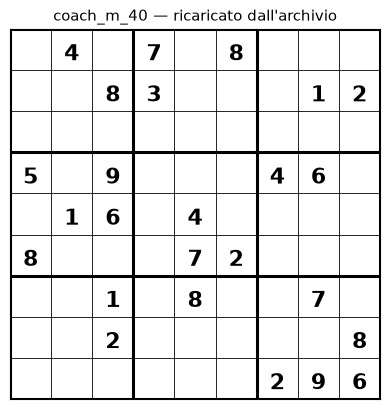

In [4]:
#loaded_info = sa.load_sudoku('coach_dev_1')
loaded_info = sa.load_last_sudoku()
loaded_puzzle = loaded_info["grid"]

print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


## 4. Prima analisi completa

Dato che il Sudoku è appena stato generato, la sua analisi non dovrebbe essere presente né nella cache in memoria né nell'archivio. La prima chiamata deve quindi:

1. eseguire il solver;
2. costruire la catena logica;
3. valutare la difficoltà;
4. salvare automaticamente l'analisi;
5. inserirla nella cache in memoria.


In [5]:
start = time.perf_counter()

first_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
)

first_elapsed = time.perf_counter() - start

print("Prima analisi completata")
print("Tempo:", round(first_elapsed, 4), "secondi")
print("Stato:", first_result["status"])
print("Valutazione:", first_result["grading"])
print("Numero di step:", len(first_result["chain"]))


Prima analisi completata
Tempo: 0.0068 secondi
Stato: solved
Valutazione: {'label': 'Fondamentale', 'max_difficulty': 1.5, 'max_level': 1, 'score': 0, 'workload_score': 0, 'perceived_difficulty': 1.962818211104531, 'max_perceived_step': -0.1989700043360188, 'histogram': {1: 56, 2: 0, 3: 0, 4: 0, 5: 0}, 'se_histogram': {'1.0': 19, '1.2': 34, '1.5': 3}, 'status': 'solved', 'n_steps': 56, 'hardest_steps': 3, 'nontrivial_steps': 0, 'advanced_steps': 0}
Numero di step: 56


## 5. Visualizzazione della griglia risolta


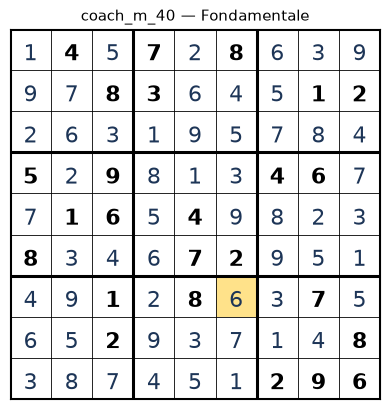

In [6]:
clues = ss.trivialize_greedy(loaded_puzzle)
sv.draw_grid(
    first_result["solved_grid"],
    given_mask=(first_result["original"] != 0),
    title=(
        f"{first_result['name']} — "
        f"{first_result['grading']['label']}"
    ),
    highlight=clues['highlight']
)
plt.show()

## 6. Catena di difficoltà

Mostra il livello di difficoltà usato a ogni step e il numero complessivo di passaggi per livello.


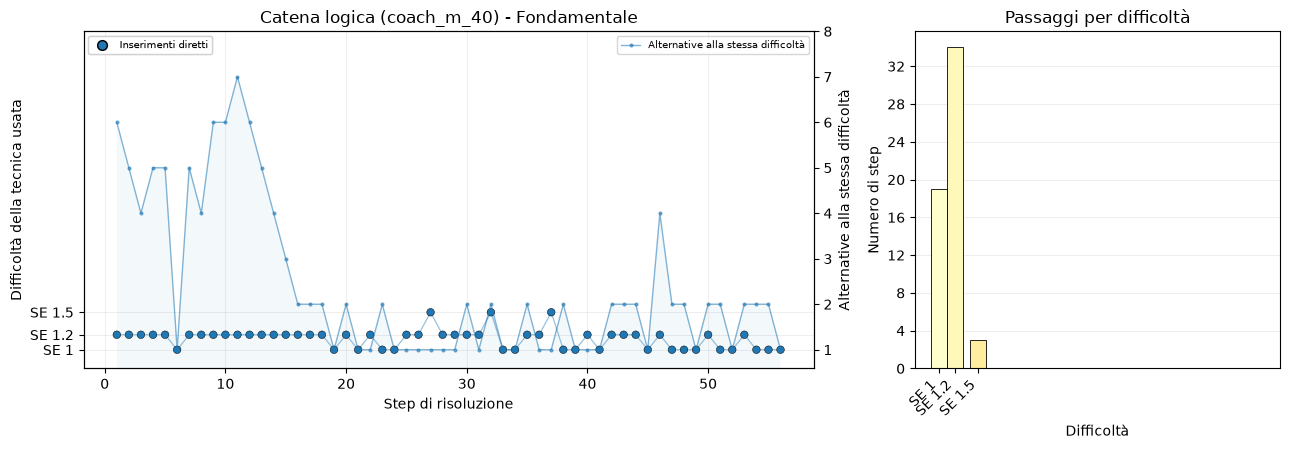

In [7]:
sv.plot_difficulty_chain(first_result)

## 7. Passaggio più difficile

Viene visualizzato lo stato della griglia in corrispondenza del passaggio con difficoltà massima.


Indice: 26
Step: 27
Tecnica: Hidden Single (Row/Column)
Difficoltà: 1.5
Descrizione: Nel col che contiene R3C4, il numero 1 puo comparire solo li.


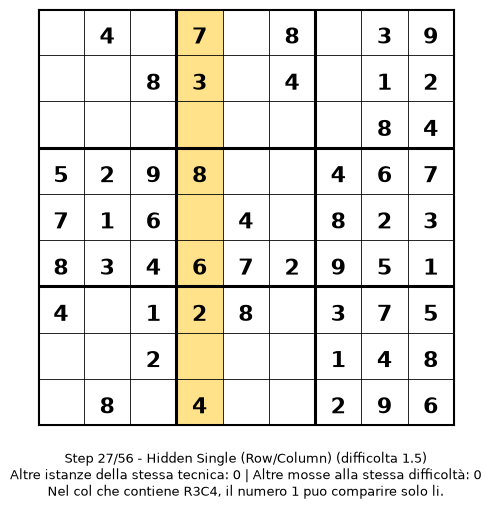

In [ ]:
if first_result["chain"]:
    hardest_index = max(
        range(len(first_result["chain"])),
        key=lambda index: first_result["chain"][index]["difficulty"],
    )

    hardest_move = first_result["chain"][hardest_index]

    print("Indice:", hardest_index)
    print("Step:", hardest_move["step"])
    print("Tecnica:", hardest_move["technique"])
    print("Difficoltà:", hardest_move["difficulty"])
    print("Descrizione:", hardest_move["description"])

    sv.draw_step(first_result, hardest_index)
else:
    print("Nessun passaggio disponibile.")


## 8. Tabella completa della catena


In [ ]:
chain_dataframe = sv.summary_dataframe(first_result)
chain_dataframe


,step,tecnica,famiglia,difficolta,n_alternative,descrizione
0,1,Hidden Single (Box),Inserimenti diretti,1.2,70,"Nel box che contiene R6C3, il numero 4 puo com..."
1,2,Hidden Single (Box),Inserimenti diretti,1.2,63,"Nel box che contiene R6C4, il numero 6 puo com..."
2,3,Hidden Single (Box),Inserimenti diretti,1.2,68,"Nel box che contiene R5C8, il numero 2 puo com..."
3,4,Hidden Single (Box),Inserimenti diretti,1.2,68,"Nel box che contiene R4C2, il numero 2 puo com..."
4,5,Hidden Single (Box),Inserimenti diretti,1.2,58,"Nel box che contiene R5C1, il numero 7 puo com..."
5,6,Last Value,Inserimenti diretti,1.0,66,R6C2 è l ultima cella vuota del box: deve cont...
6,7,Hidden Single (Box),Inserimenti diretti,1.2,65,"Nel box che contiene R4C9, il numero 7 puo com..."
7,8,Hidden Single (Box),Inserimenti diretti,1.2,57,"Nel box che contiene R5C7, il numero 8 puo com..."
8,9,Hidden Single (Box),Inserimenti diretti,1.2,61,"Nel box che contiene R3C8, il numero 8 puo com..."
9,10,Hidden Single (Box),Inserimenti diretti,1.2,56,"Nel box che contiene R3C9, il numero 4 puo com..."


## 9. Frequenza delle tecniche effettivamente usate


In [ ]:
technique_counts = (
    chain_dataframe["tecnica"]
    .value_counts()
    .rename_axis("tecnica")
    .reset_index(name="numero_step")
)

technique_counts


,tecnica,numero_step
0,Hidden Single (Box),34
1,Last Value,19
2,Hidden Single (Row/Column),3


## 10. Attività delle tecniche durante la risoluzione

Se `sudoku_visualization.py` contiene `plot_technique_activity`, viene mostrata la heatmap con:

- righe: tecniche;
- colonne: step;
- valori: numero di applicazioni disponibili in quello stato.

Le analisi devono contenere `applicable_by_technique` perché questa visualizzazione sia significativa.


COME SONO CONTATE LE MOSSE CHE COINVOLGONO più CASELLE?

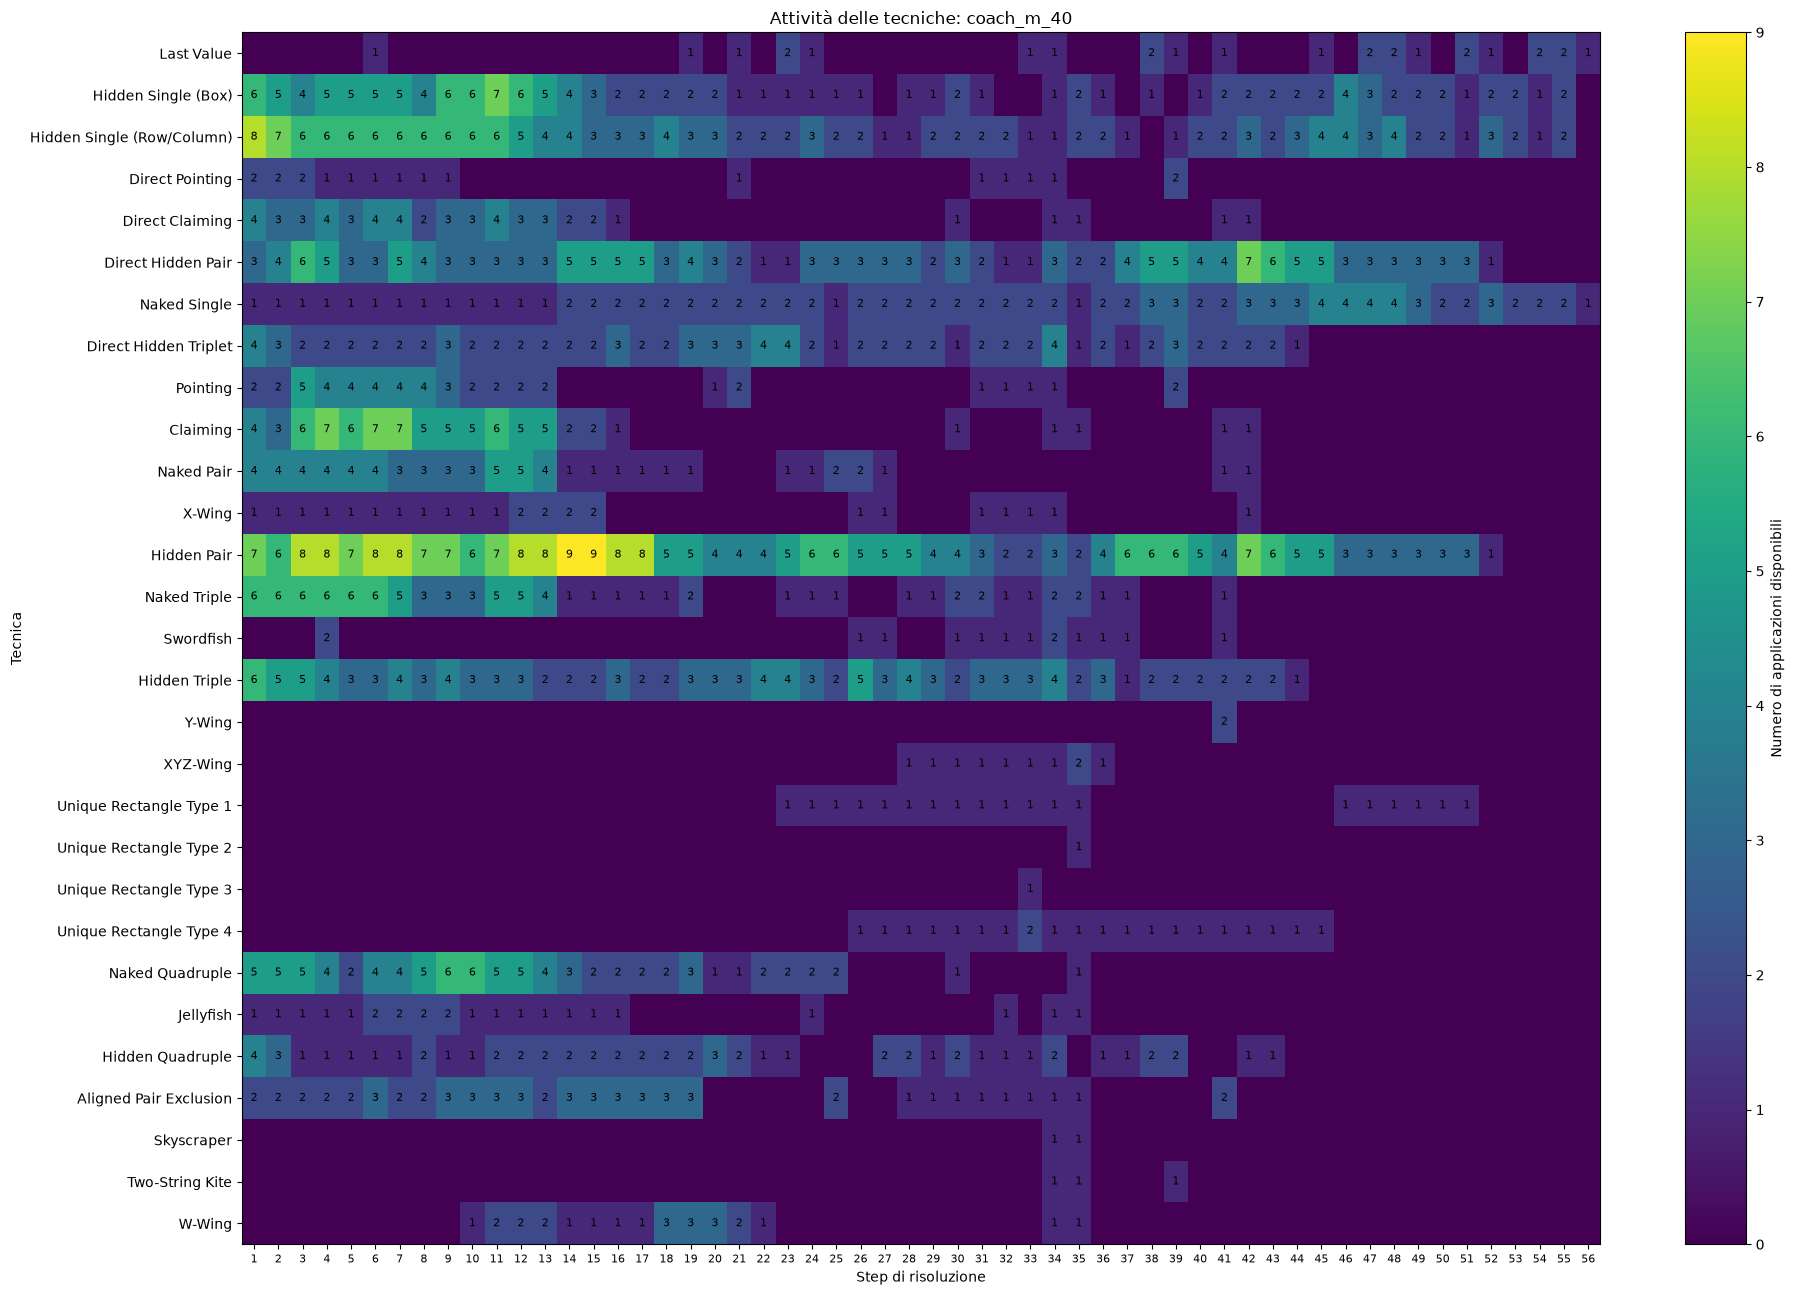

In [ ]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )
